[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mpho-sadiki/deafrica-direct-access/blob/sen1flood11/Real_world_examples/Flood_extent_mapping_DL/Flood_mapping_Deep_Learning.ipynb)

#Sentinel-1 Flood Detection with Deep Learning

## Background
Flooding is one of the most widespread and damaging natural hazards, with major impacts on people, infrastructure, and ecosystems. Mapping flood extent quickly and accurately is essential for disaster response, recovery planning, and long-term resilience. While optical satellite imagery has traditionally been used for water detection, its effectiveness is limited by cloud cover and daylight. Synthetic Aperture Radar (SAR), such as data from the Sentinel-1 mission, provides an all-weather, day-night capability, making it particularly useful for flood monitoring.

The [Sen1Floods11](https://github.com/cloudtostreet/Sen1Floods11/tree/master) dataset was developed to advance machine learning applications in flood mapping. It provides a large collection of Sentinel-1 SAR scenes paired with high-quality flood labels, enabling the training and evaluation of deep learning models for flood detection. Models trained on Sen1Floods11, such as FCN-ResNet architectures, can generalize to unseen regions and produce robust predictions of water extent.
In this notebook, we apply a pretrained FCN-ResNet50 model trained on Sen1Floods11 to Sentinel-1 SAR time series data. The FCN-ResNet50 model applied here was trained using the original [Sen1Floods11 training workflow](https://github.com/cloudtostreet/Sen1Floods11/blob/master/Train.ipynb). For practical reasons, the number of training epochs was reduced from 1000 to 250 due to GPU memory constraints. No other changes were made to the model architecture or preprocessing steps. Users who wish to retrain or fine-tune the model should consult the original Sen1Floods11 code to adjust hyperparameters or modify the training procedure. The figure below shows the model’s training and validation performance to provide context on the model’s quality and reliability.


For this analysis, the Sentinel-1 SAR time series data were accessed through Digital Earth Africa (DE Africa) using direct access via the STAC API. DE Africa provides pre-processed, Analysis Ready Data (ARD) including Radiometrically Terrain Corrected (RTC) Sentinel-1 products, which are suitable for deep learning-based flood mapping.
The Sen1Floods11 model was trained on Sentinel-1 GRD products in decibel (dB) units. Our analysis uses Radiometrically Terrain Corrected (RTC) products, which are provided as linear intensity. For consistency with the model, the linear intensity is converted to dB before input. While RTC processing introduces slight differences in backscatter compared to GRD, these are minor, and the model remains effective for detecting pre-flood, post-flood, and newly inundated areas.

This notebook demonstrates how to preprocess SAR inputs, generate flood extent predictions, visualize temporal dynamics, and quantify changes in water coverage. Both the original Sen1Floods11 training and the analyses in this notebook were performed in [Google Colab](https://colab.google/).

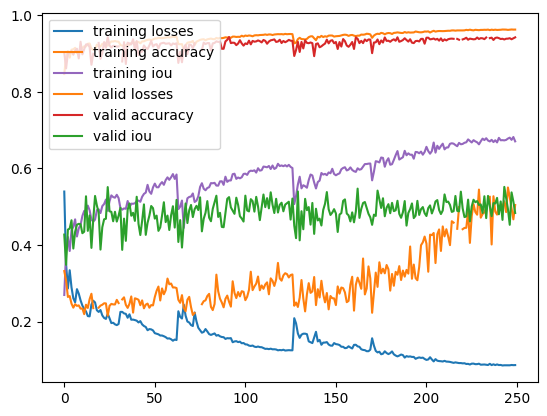

Figure 1. Training and validation performance of the FCN-ResNet50 model on the Sen1Floods11 dataset. The plots show the evolution of loss, accuracy, and Intersection over Union (IoU) over 250 epochs.

Figure 1 above shows the evolution of training and validation metrics for the FCN-ResNet50 model trained on the Sen1Floods11 dataset. The training loss (blue) declines steadily, indicating effective optimisation, while the validation loss follows a similar trend before rising slightly after about 200 epochs, marking the point of optimal generalisation. Both training and validation accuracy (orange and red) increase together and remain closely aligned, showing that the model generalizes well without significant overfitting. The training IoU (purple) improves progressively, and the validation IoU (green) rises during early training before stabilizing around 0.5, demonstrating consistent predictive performance on unseen data.

Overall, these trends indicate that the network learned effectively and reached convergence by roughly 200 epochs. Extending training to 250 epochs confirmed that performance had stabilised and no further improvement was observed, as shown by the flattening of the accuracy and IoU curves and the slight upturn in validation loss toward the end of training. This behavior confirmed that the model had achieved a balanced trade-off between fitting the training data and maintaining generalisation, making the 250-epoch checkpoint appropriate for flood-extent prediction in the present analysis.

## Install Dependencies

In [1]:
!pip install deafrica-tools pystac-client odc-stac geopandas xarray rioxarray scikit-image matplotlib seaborn pandas --quiet
!pip install session_info


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.1/543.1 kB 15.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.0/264.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Import libraries and show environment info

In [2]:
import session_info
import odc.algo
import folium
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from skimage.filters import threshold_otsu
from scipy.ndimage import uniform_filter

from pystac_client import Client
from odc.stac import configure_rio, stac_load
from deafrica_tools.plotting import rgb
from deafrica_tools.get_config import get_product_config
from deafrica_tools.plotting import display_map


### Session Info

When working across different environments, it's helpful to display the software 'image' under which the script was developed. The cell below uses the `session_info` package to show package and Python versions used. This could be helpful if you experience bugs or software conflights when applying this script as you can refer to the package and Python versions below.

In [3]:
# Show environment info for reproducibility
session_info.show()

/usr/local/lib/python3.12/dist-packages/session_info/main.py:213: FutureWarning: accessing cuda.__version__ is deprecated, please switch to use cuda.bindings.__version__ instead
  mod_version = _find_version(mod.__version__)


## Configure Sentinel-1 Data

The first Digital Earth Africa product we'll load is the Sentinel-1 RTC. To do this, we have to set the data configuration as per the cell below. The configuration is set as a dictionary object (`dict`) in Python.

We can use the `get_product_config` function from Digital Earth Africa tools to help build the dictionary.

In [4]:
# Get configuration for Sentinel-1 RTC
config = get_product_config("s1_rtc", profile="deafrica")
configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
    AWS_S3_ENDPOINT="s3.af-south-1.amazonaws.com",
)
# Open the STAC catalog
catalog = Client.open("https://explorer.digitalearth.africa/stac")


## Set area and period of interest
For this analysis, the area of interest is **Garissa County, Kenya**, which experienced severe flooding during the March to May 2024 rainy season. Heavy rains upstream in the Tana River basin caused rivers, including the Tana River, to overflow, resulting in localised inundation, displacement of communities, and damage to infrastructure. While the floods peaked in late April 2024, widespread impacts, including standing water in low-lying areas and disrupted transportation networks, persisted into early May.

Similar to working with any other spatiotemporal data, we set our area of interest with a bounding box and period of interest with a start and end date.

In [5]:
# Define bounding box
lat, lon = -0.451460, 39.631158

buffer = 0.1
bbox = [lon - buffer, lat - buffer, lon + buffer, lat + buffer]

# Define time range
start_date = "2024-02-01"
end_date = "2024-05-30"

In [6]:
lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

display_map(lon_range, lat_range)


Build a STAC query based on the area and period of interest. This cell returns the number of datasets that match our STAC query. Note that these may represent different times, or they may be datasets that overlap in space (if there are multiple matches).

In [7]:
# Search for S1 RTC collections
collections = ["s1_rtc"]
query = catalog.search(bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}")
items = list(query.items())
print(f"Found: {len(items)} datasets")

Found: 10 datasets



Next, we set the parameters for data loading such as the coordinate reference system (crs) and bands we want to load using the stac_load function.

This returns an xarray object which makes it easy to deal with numerous dimensions.

In [8]:
crs = "EPSG:6933"
resolution = 20

ds = stac_load(
    items,
    bands=("vv", "vh"),
    crs=crs,
    resolution=resolution,
    chunks={},
    stac_cfg=config,
    bbox=bbox,
)

ds  # check dataset structure


<xarray.Dataset> Size: 99MB
Dimensions:      (y: 1277, x: 966, time: 10)
Coordinates:
  * y            (y) float64 10kB -4.483e+04 -4.485e+04 ... -7.035e+04
  * x            (x) float64 8kB 3.814e+06 3.814e+06 ... 3.833e+06 3.834e+06
  * time         (time) datetime64[ns] 80B 2024-02-02T15:40:06.434849 ... 202...
    spatial_ref  int32 4B 6933
Data variables:
    vv           (time, y, x) float32 49MB dask.array<chunksize=(1, 1277, 966), meta=np.ndarray>
    vh           (time, y, x) float32 49MB dask.array<chunksize=(1, 1277, 966), meta=np.ndarray>

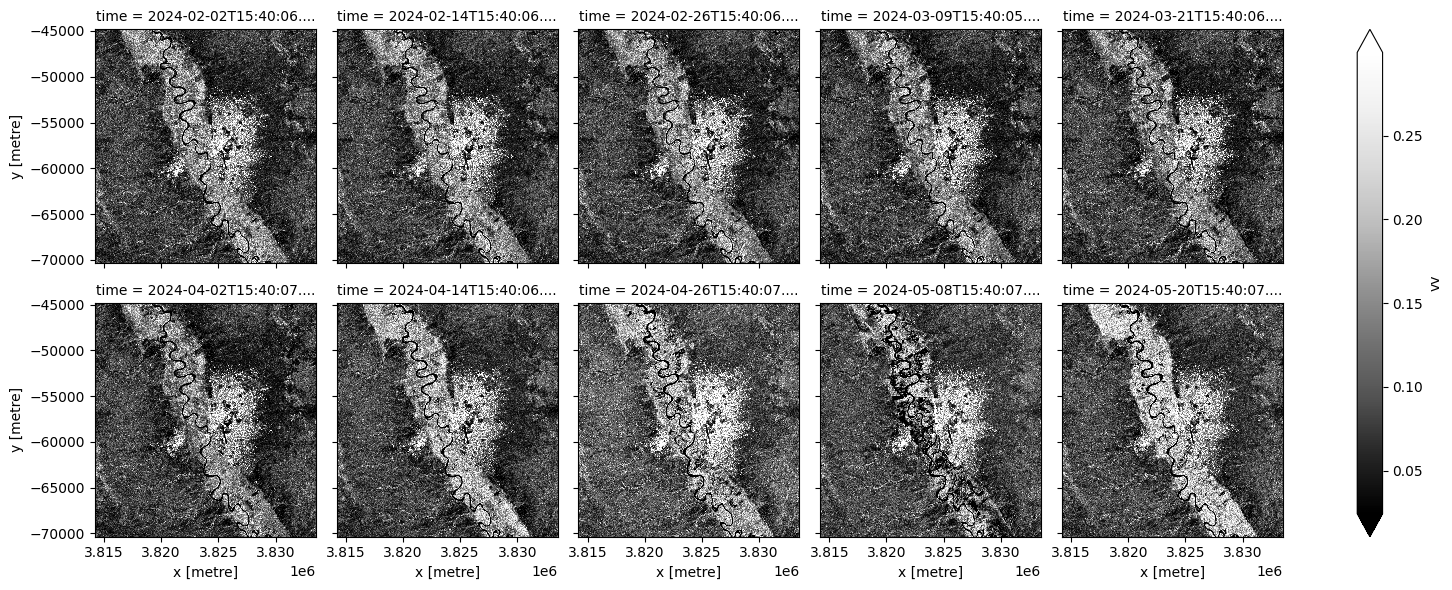

In [9]:
ds.vv.plot(cmap="Greys_r", robust=True, col="time", col_wrap=5)

## Select Pre- and Post-flood images
After loading the dataset, you can inspect the available timestamps using `ds["time"]`.values to see all the dates of the images. The images are indexed starting from 0, so the first image has index 0, the second has index 1, and so on. You can select the pre-event (before the flood) and post-event (after the flood) images either by index using ds.isel`(time=[t0, t1])`. After selection, the dataset will only contain the chosen timestamps, making it ready for flood prediction and comparison.

This analysis uses a pre-flood reference image from February 2024 and a post-flood image from May 8, 2024. Although peak flooding occurred around late April, the May 8 image captures residual inundation and areas that remained waterlogged or affected by the flood. This provides a reliable basis for detecting flood extent and impacts.

In [10]:
# Select pre- and post-event images
t0, t1 = 0, 8

# Subset the dataset to only these two times
ds = ds.isel(time=[t0, t1])

# Check the resulting dataset
ds


<xarray.Dataset> Size: 20MB
Dimensions:      (y: 1277, x: 966, time: 2)
Coordinates:
  * y            (y) float64 10kB -4.483e+04 -4.485e+04 ... -7.035e+04
  * x            (x) float64 8kB 3.814e+06 3.814e+06 ... 3.833e+06 3.834e+06
  * time         (time) datetime64[ns] 16B 2024-02-02T15:40:06.434849 2024-05...
    spatial_ref  int32 4B 6933
Data variables:
    vv           (time, y, x) float32 10MB dask.array<chunksize=(1, 1277, 966), meta=np.ndarray>
    vh           (time, y, x) float32 10MB dask.array<chunksize=(1, 1277, 966), meta=np.ndarray>

## Prepare model
Load the pretrained flood prediction model based on FCN-ResNet50, modified to accept two input channels corresponding to the VV and VH Sentinel-1 bands. Batch normalization layers in the network are converted to group normalization to improve stability during inference. The model weights are downloaded directly from the `GitHub repository (sen1floods11_model.pth)` and loaded into the network. The network is set to evaluation mode, preparing it for running predictions on the Sentinel-1 time series without updating any parameters.

In [11]:
# Load FCN-ResNet50 model with 2 input channels
net = models.segmentation.fcn_resnet50(pretrained=False, num_classes=2, pretrained_backbone=False)
net.backbone.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Convert BatchNorm to GroupNorm
def convertBNtoGN(module, num_groups=16):
    if isinstance(module, nn.BatchNorm2d):
        return nn.GroupNorm(num_groups, module.num_features, eps=module.eps, affine=module.affine)
    for name, child in module.named_children():
        module.add_module(name, convertBNtoGN(child, num_groups=num_groups))
    return module

net = convertBNtoGN(net)

# Load checkpoint
!wget -O /content/sen1floods11_model.pth \
https://github.com/digitalearthafrica/deafrica-direct-access/raw/main/Real_world_examples/Flood_extent_mapping_DL/sen1floods11_model.pth
checkpoint_path = "/content/sen1floods11_model.pth"
net.load_state_dict(torch.load(checkpoint_path, map_location='cuda' if torch.cuda.is_available() else 'cpu'))
net.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to 

--2025-12-02 07:27:24--  https://github.com/mpho-sadiki/deafrica-direct-access/raw/sen1flood11/Real_world_examples/Flood_extent_mapping_DL/sen1floods11_model.pth
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mpho-sadiki/deafrica-direct-access/sen1flood11/Real_world_examples/Flood_extent_mapping_DL/sen1floods11_model.pth [following]
--2025-12-02 07:27:24--  https://raw.githubusercontent.com/mpho-sadiki/deafrica-direct-access/sen1flood11/Real_world_examples/Flood_extent_mapping_DL/sen1floods11_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65941847 (63M) [application/octet-stream]
Sav

FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): GroupNorm(16, 64, eps=1e-05, affine=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): GroupNorm(16, 64, eps=1e-05, affine=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): GroupNorm(16, 64, eps=1e-05, affine=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): GroupNorm(16, 256, eps=1e-05, affine=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): GroupNorm(16, 256, eps=1e-05, affine=True)
        )
  

## Run Flood Prediction over Time Series
For each time step in the Sentinel-1 RTC dataset, the VV and VH backscatter bands are preprocessed and passed into the deep learning model.

**Note:** The FCN-ResNet50 model was originally trained on Sentinel-1 GRD data. When applied to RTC data, slight differences in backscatter intensity can occur due to terrain correction. GRD-based normalization is therefore applied to minimize distribution mismatch, although minor residual biases may remain.

**Processing steps:**
1. **Handle missing data:** Replace NaN values with the mean of valid pixels to avoid introducing artifacts.  
2. **Transform inputs:** Convert VV and VH from linear intensity to decibel (dB) scale using `10 × log10(x + 1e-10)`. The tiny constant `1e-10` prevents mathematical errors when pixel values are zero or extremely small, which would otherwise cause undefined results in the logarithm.
Values are then clipped to the range [−55, 5] dB to accommodate RTC brightness and rescaled to [0, 1].
3. **Prepare tensors:** Stack VV and VH into a two-channel tensor and normalize using the GRD statistics from model training to ensure consistent input distributions.  
4. **Model inference:** The FCN-ResNet50 network predicts water versus non-water for each pixel at every time step.  
5. **Mask invalid areas:** Predictions corresponding to NaN locations are set to 255 to mark them as invalid.

The resulting binary classification masks are stored in the list `predictions`, one mask per time step. Each mask encodes `water (1)`, `non-water (0)`, and `invalid areas (255)`.


In [12]:
device = next(net.parameters()).device

# GRD stats from your model training
grd_stats = ([0.6851, 0.5235], [0.0820, 0.1102])

# Preprocess function using GRD stats
def preprocess_vv_vh(vv, vh, clip_db=(-55, 5), norm_stats=None):
    nan_mask = np.isnan(vv) | np.isnan(vh)
    vv_filled = np.nan_to_num(vv, nan=np.nanmean(vv))
    vh_filled = np.nan_to_num(vh, nan=np.nanmean(vh))

    # Convert to dB
    vv_db = 10 * np.log10(vv_filled + 1e-10)
    vh_db = 10 * np.log10(vh_filled + 1e-10)

    # Clip and scale to 0-1
    min_db, max_db = clip_db
    vv_scaled = (np.clip(vv_db, min_db, max_db) - min_db) / (max_db - min_db)
    vh_scaled = (np.clip(vh_db, min_db, max_db) - min_db) / (max_db - min_db)

    tensor = torch.stack([
        torch.from_numpy(vv_scaled).float(),
        torch.from_numpy(vh_scaled).float()
    ])

    # Use GRD stats for normalization
    if norm_stats is None:
        raise ValueError("norm_stats must be provided for GRD normalization on RTC")

    (vv_mean, vh_mean), (vv_std, vh_std) = norm_stats
    norm = transforms.Normalize([vv_mean, vh_mean], [vv_std, vh_std])
    tensor = norm(tensor).unsqueeze(0).to(device)

    return tensor, nan_mask, vv_scaled, vh_scaled

# Prediction loop for RTC using GRD stats
water_probs_list = []
predictions = []
nan_masks = []
normed_vv = []
normed_vh = []

for t in range(ds.sizes["time"]):
    vv = ds["vv"].isel(time=t).data.compute()
    vh = ds["vh"].isel(time=t).data.compute()

    tensor, nan_mask, vv_s, vh_s = preprocess_vv_vh(vv, vh, norm_stats=(grd_stats[0], grd_stats[1]))

    normed_vv.append(vv_s)
    normed_vh.append(vh_s)

    # Model prediction
    net.eval()
    with torch.no_grad():
        output = net(tensor)["out"]
        pred = torch.argmax(output, dim=1).squeeze().cpu().numpy().astype(np.uint8)
        probs = torch.softmax(output, dim=1)[0,1].cpu().numpy()  # water probability

    pred[nan_mask] = 255

    predictions.append(pred)
    water_probs_list.append(probs)
    nan_masks.append(nan_mask)

    print(f"Time step {t} prediction unique values: {np.unique(pred)}")


Time step 0 prediction unique values: [0 1]
Time step 1 prediction unique values: [0 1]


## Visualize flood predictions

The prediction masks for the two time steps are displayed side by side, showing pre-flood and post-flood conditions. Gray indicates land and blue represents water. This layout allows for easy visual comparison of water extent changes between the two dates.

Some water areas visible in post-flood imagery may not appear in the model predictions, even if they were detected pre-flood. This can happen because:

* Changed surface conditions: Flooded areas may carry sediment, debris, or reflect differently due to wet soil or vegetation, altering radar backscatter compared to what the model was trained on.
* Surface roughness and inundation dynamics: Water interacting with vegetation, buildings, or terrain can produce complex backscatter patterns that the model may under-predict.
* Radar geometry effects: Slopes or viewing angles may reduce radar return, especially along edges or high-water areas, causing some pixels to fall below the detection threshold.

To identify the flood-affected areas, we compute changes between pre-flood and post-flood predictions. Pixels detected as water in the pre-flood image are considered permanent water, while pixels that appear as water only in the post-flood image represent flooded areas. Pixels that disappear as water in the post-flood image are flagged as lost water, though these often reflect model under-prediction rather than true water loss. This difference-based approach allows for a clear separation of permanent and newly flooded areas.


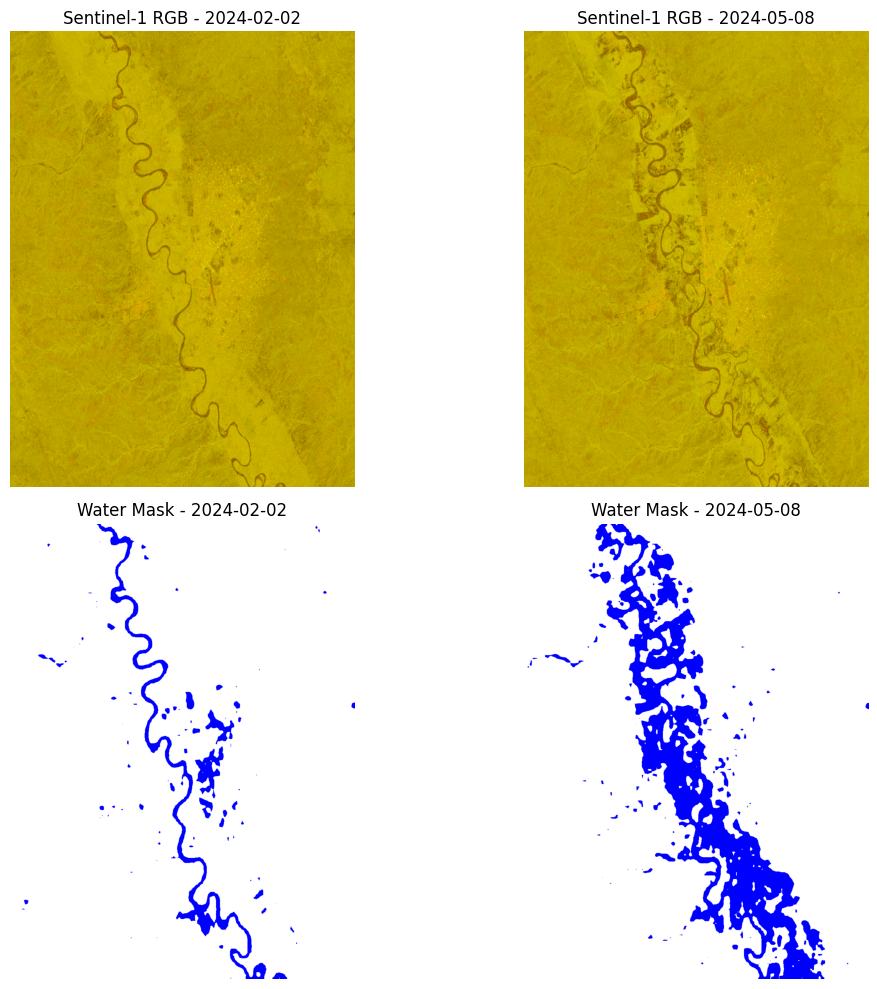

In [13]:
# Number of timesteps
n_times = len(predictions)

# Convert times to strings (e.g., YYYY-MM-DD)
time_labels = [pd.to_datetime(ds.time.values[t]).strftime("%Y-%m-%d") for t in range(n_times)]

fig, axes = plt.subplots(2, n_times, figsize=(6 * n_times, 10))

for t in range(n_times):
    # --- Top row: RGB VV/VH ---
    vv_img = normed_vv[t]
    vh_img = normed_vh[t]
    rgb_img = np.zeros((vv_img.shape[0], vv_img.shape[1], 3), dtype=np.float32)
    rgb_img[..., 0] = vv_img  # Red
    rgb_img[..., 1] = vh_img  # Green

    axes[0, t].imshow(rgb_img)
    axes[0, t].set_title(f"Sentinel-1 RGB - {time_labels[t]}")
    axes[0, t].axis("off")

    # --- Bottom row: Predicted mask ---
    mask = predictions[t]
    mask_plot = np.where(mask == 255, np.nan, mask)
    cmap = mcolors.ListedColormap(["white", "blue"])
    axes[1, t].imshow(mask_plot, cmap=cmap, vmin=0, vmax=1)
    axes[1, t].set_title(f"Water Mask - {time_labels[t]}")
    axes[1, t].axis("off")

plt.tight_layout()
plt.show()


## Water extent change

Compares water extent between two selected timestamps and visualizes the changes.

Each pixel is categorized as one of three classes:

* Permanent Water (Water → Water): areas that were water in both the baseline (pre-flood) and post-flood images, shown in blue. This stricter definition avoids including areas misclassified as water in the pre-flood image (e.g., bare land or roads).

* Flooded Water (No Water → Water): areas that were dry in the baseline but became water in the post-flood image, shown in green. These represent newly inundated areas due to flooding.

* Optional total post-flood water: all water present in the post-flood image, for context.

#### Notes on pre-flood water not being picked up post-flood:

* Some pixels classified as water in the pre-flood image may appear dry in the post-flood image due to natural variation in backscatter (e.g., seasonal changes, soil moisture differences, or temporary drying).

* To address this, permanent water is defined as water present in both pre- and post-flood images. This ensures that transient misclassifications or temporary changes do not artificially inflate permanent water estimates.

* Any water in the pre-flood image that is not present post-flood is excluded from the permanent water class but still visible in the original probability maps, allowing inspection of temporary changes or possible misclassifications.

The legend reports approximate area (in km²) for each category, providing quantitative context for changes in water coverage.


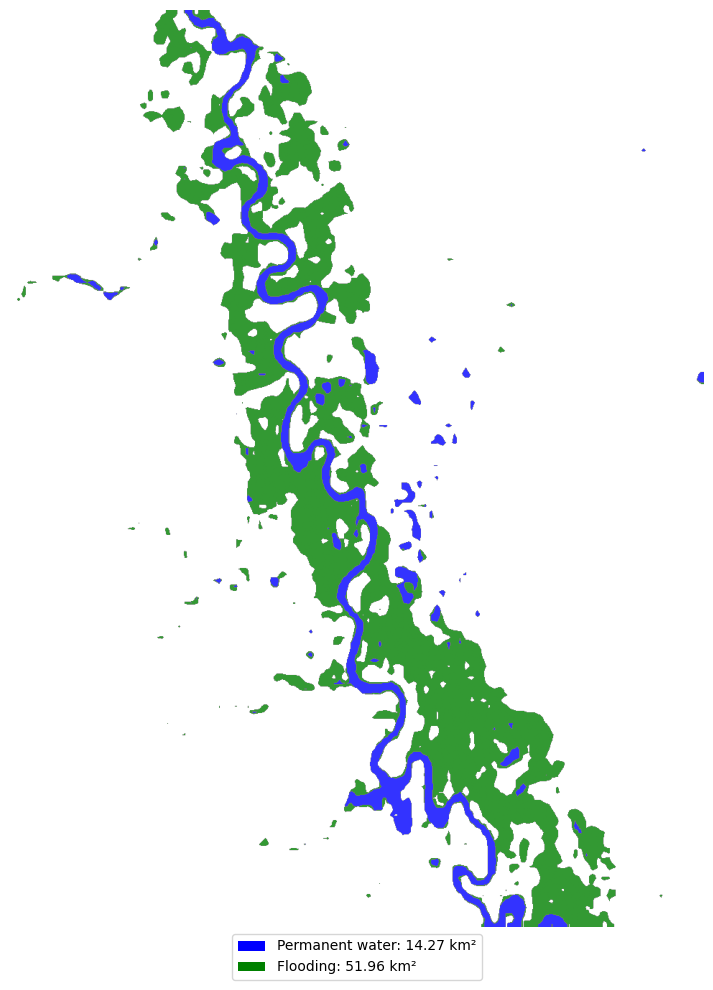

In [14]:
# Pick two timestamps
t0, t1 = 0, 1  # pre-flood and post-flood
pred0 = predictions[t0]
pred1 = predictions[t1]

# Mask invalid pixels
valid_mask = (pred0 != 255) & (pred1 != 255)

# Permanent water: water present in both pre- and post-flood
permanent_water = np.where((pred0 == 1) & (pred1 == 1) & valid_mask, 1, np.nan)

# Flooded water: water in post-flood but not permanent
flooded_water = np.where((pred1 == 1) & (permanent_water != 1) & valid_mask, 1, np.nan)

# Total post-flood water (optional)
total_post_water = np.where((pred1 == 1) & valid_mask, 1, np.nan)

# Compute areas
area_per_pixel = (resolution ** 2) / 1_000_000  # km²
permanent_area = np.nansum(permanent_water) * area_per_pixel
flooded_area = np.nansum(flooded_water) * area_per_pixel
total_post_area = np.nansum(total_post_water) * area_per_pixel

# Colors
permanent_color = "blue"
flooded_color = "green"

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(permanent_water, cmap=ListedColormap([permanent_color]), alpha=0.8)
ax.imshow(flooded_water, cmap=ListedColormap([flooded_color]), alpha=0.8)

# Legend
plt.legend(
    [
        Patch(facecolor=permanent_color),
        Patch(facecolor=flooded_color),
    ],
    [
        f"Permanent water: {round(permanent_area, 2)} km²",
        f"Flooding: {round(flooded_area, 2)} km²",
    ],
    loc='upper center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
)

plt.axis("off")
plt.tight_layout()
plt.show()


## Interactive water change map

This interactive map shows water extent changes over the selected period on top of an Esri satellite basemap. Blue areas represent permanent water and green areas indicate newly appeared water (flooded). You can zoom and pan to explore the changes in detail. The fixed legend in the bottom left provides a quick reference for the three classes.

> Note: Some areas that appear as permanent water may correspond to bare soil or paved roads, or flat exposed surfaces. These surfaces can produce backscatter signatures in Sentinel-1 that are similar to water. Defining permanent water as water present in both pre- and post-flood images helps reduce these misclassifications, but some isolated pixels may still appear incorrectly.



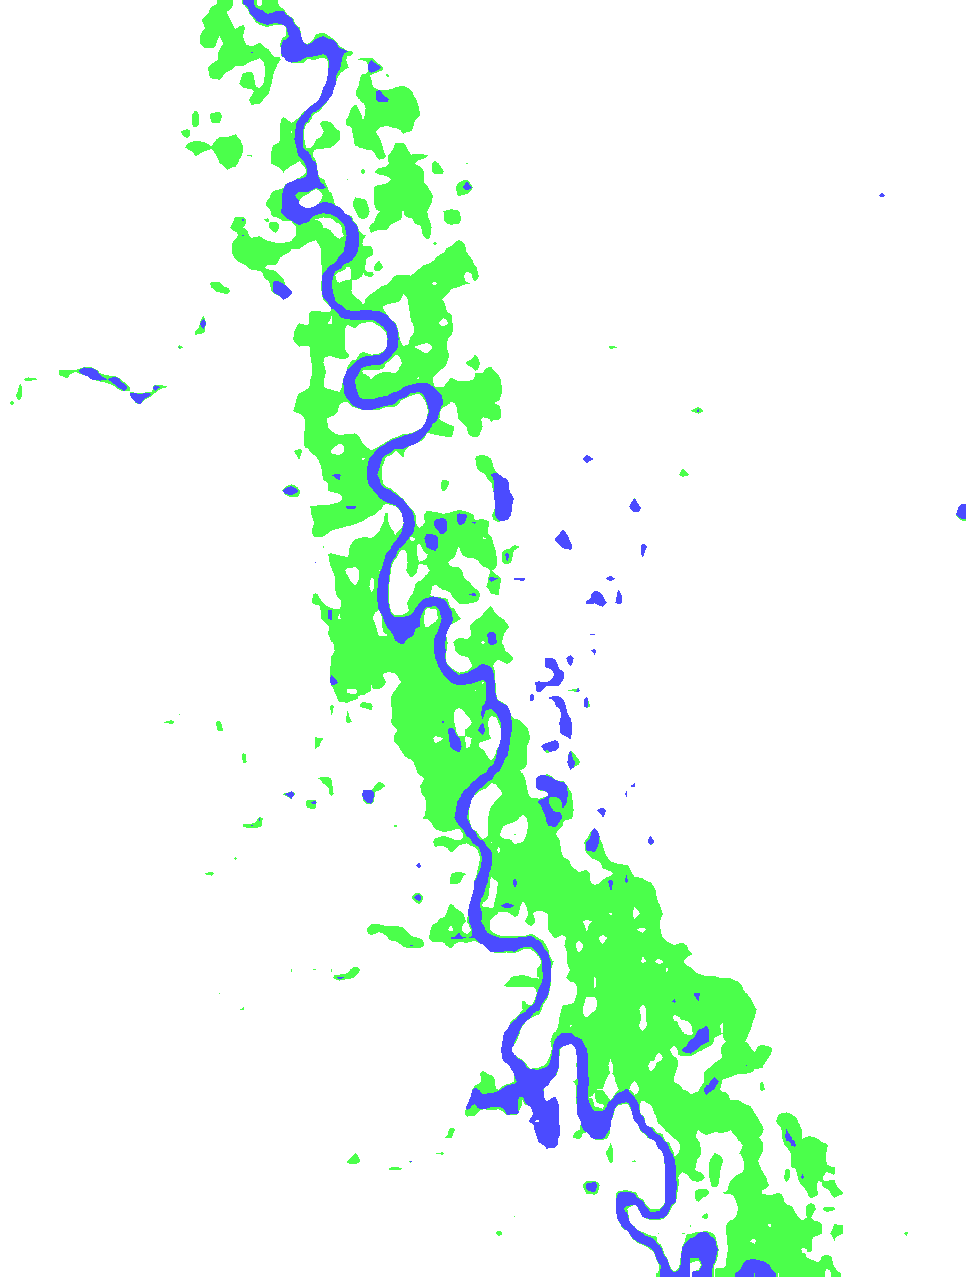

In [15]:
# Convert to 0/1 for water
water0 = np.where(pred0 == 1, 1, 0)
water1 = np.where(pred1 == 1, 1, 0)

# Compute change
change = water1 - water0  # 1 = appeared, -1 = disappeared, 0 = stable or land
change = np.where(valid_mask, change, np.nan)

# Now you can create an RGB array for Folium
rgb = np.zeros((change.shape[0], change.shape[1], 4), dtype=np.uint8)
rgb[~np.isnan(permanent_water)] = [0, 0, 255, 180]       # blue
rgb[~np.isnan(flooded_water)] = [0, 255, 0, 180]        # green

# Overlay on Folium
m = folium.Map(
    location=[(bbox[1] + bbox[3]) / 2, (bbox[0] + bbox[2]) / 2],
    zoom_start=12,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=rgb,
    bounds=[[bbox[1], bbox[0]], [bbox[3], bbox[2]]],
    opacity=0.8,
).add_to(m)

# Legend
legend_html = """
<div style="
    position: fixed;
    bottom: 20px; left: 20px; width: 180px; height: 100px;
    background-color: white; z-index:9999; font-size:14px;
    border:2px solid grey; padding: 10px;">
<b>Water Change</b><br>
<i style="background:blue; width:15px; height:15px; float:left; margin-right:5px; opacity:0.7"></i> Permanent Water<br>
<i style="background:green; width:15px; height:15px; float:left; margin-right:5px; opacity:0.7"></i> Flooding
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m


---

## Additional information

<b> License </b> The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

<b> Contact </b> If you need assistance, please post a question on the [DE Africa Slack channel](https://digitalearthafrica.slack.com/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Last Tested:**

In [16]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-02'